# Image Captioning – Data & Training (v5 · EfficientNet-B4 + Attention)

In [1]:
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

In [2]:
import zipfile
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")
_kaggle_ds   = next(KAGGLE_INPUT.iterdir(), None) if KAGGLE_INPUT.exists() else None

DATA_DIR = Path("caption_data")
IMG_DIR  = DATA_DIR / "Images"

def _has_images(d):
    return d.exists() and len(list(d.glob("*.jpg"))) >= 100

def _has_captions(d):
    return (d / "captions.txt").exists() or (d / "captions").exists()

def _find_zip():
    candidates = [Path("caption_data.zip"), Path("/content/caption_data.zip")]
    if _kaggle_ds:
        candidates += list(_kaggle_ds.rglob("*.zip"))
    return next((p for p in candidates if p.exists()), None)

def _find_kaggle_images():
    if not KAGGLE_INPUT.exists():
        return None
    for jpg in KAGGLE_INPUT.rglob("*.jpg"):
        return jpg.parent
    return None

def _unzip(zip_path):
    print(f"Unzipping {zip_path}...")
    with zipfile.ZipFile(zip_path, "r") as z:
        names    = z.namelist()
        has_root = any(n.startswith("caption_data/") for n in names)
        if has_root:
            z.extractall(".")
        else:
            DATA_DIR.mkdir(exist_ok=True)
            z.extractall(str(DATA_DIR))
    if _has_images(IMG_DIR) and _has_captions(DATA_DIR):
        print(f"Done: {len(list(IMG_DIR.glob('*.jpg')))} images.")
    else:
        print("WARNING: unexpected layout. Contents:", [p.name for p in DATA_DIR.iterdir()][:10])

if _has_images(IMG_DIR) and _has_captions(DATA_DIR):
    print(f"Dataset ready — {len(list(IMG_DIR.glob('*.jpg')))} images.")
elif (_kaggle_imgs := _find_kaggle_images()):
    IMG_DIR = _kaggle_imgs
    for _n in ["captions.txt", "captions"]:
        for _parent in [_kaggle_imgs.parent, _kaggle_imgs.parent.parent]:
            if (_parent / _n).exists():
                DATA_DIR = _parent
                break
    print(f"Kaggle input detected — IMG_DIR={IMG_DIR}  DATA_DIR={DATA_DIR}")
    print(f"Images: {len(list(IMG_DIR.glob('*.jpg')))}")
elif (zip_path := _find_zip()):
    _unzip(zip_path)
else:
    raise FileNotFoundError(
        "No dataset found.\n"
        f"Kaggle contents: {list(KAGGLE_INPUT.iterdir()) if KAGGLE_INPUT.exists() else 'N/A'}"
    )


Kaggle input detected — IMG_DIR=/kaggle/input/datasets/giorgitabatadze123/caption-data-zip/Images  DATA_DIR=/kaggle/input/datasets/giorgitabatadze123/caption-data-zip
Images: 8091


In [3]:
import os, re, json, math, random, pickle
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as tvm

# reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# paths — preserve what setup cell detected
if "IMG_DIR" not in dir() or not Path(str(IMG_DIR)).exists():
    DATA_DIR = Path("caption_data")
    IMG_DIR  = DATA_DIR / "Images"

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

for _n in ["captions.txt", "captions"]:
    if (DATA_DIR / _n).exists():
        CAPS_FILE = DATA_DIR / _n
        break
else:
    raise FileNotFoundError(f"No captions file in '{DATA_DIR}'.")
print(f"Captions : {CAPS_FILE}")
print(f"IMG_DIR  : {IMG_DIR}")

# ── hyper-parameters ──────────────────────────────────────────────────────────
ENCODER_DIM     = 1792   # EfficientNet-B4 feature channels
EMBED_SIZE      = 512
ATTENTION_DIM   = 512
HIDDEN_SIZE     = 512
DROPOUT         = 0.5
LABEL_SMOOTHING = 0.1
BEAM_WIDTH      = 5
MIN_FREQ        = 3      # lower threshold — pretrained encoder needs less data per word
MAX_SEQ_LEN     = 50
BATCH_SIZE      = 16     # EfficientNet-B4 is heavier; 32 keeps us in T4 VRAM
NUM_EPOCHS      = 20     # pretrained encoder converges much faster
ENCODER_LR      = 1e-4   # fine-tune encoder with low LR to preserve pretrained features
DECODER_LR      = 4e-4   # decoder trains from scratch, can use higher LR
WARMUP_EPOCHS   = 2
VAL_SPLIT       = 0.1


Device: cuda
Captions : /kaggle/input/datasets/giorgitabatadze123/caption-data-zip/captions.txt
IMG_DIR  : /kaggle/input/datasets/giorgitabatadze123/caption-data-zip/Images


In [4]:
def load_captions(path):
    raw  = path.read_text(encoding="utf-8", errors="replace").strip()
    first = raw.split("\n")[0]
    if "\t" in first:
        rows = []
        for line in raw.split("\n"):
            line = line.strip()
            if not line or "\t" not in line: continue
            img_tag, cap = line.split("\t", 1)
            rows.append({"image": img_tag.split("#")[0].strip(), "caption": cap.strip()})
        return pd.DataFrame(rows)
    lines = raw.split("\n")
    start = 1 if lines[0].strip().lower().startswith("image") else 0
    rows  = []
    for line in lines[start:]:
        line = line.strip()
        if not line or "," not in line: continue
        img, cap = line.split(",", 1)
        rows.append({"image": img.strip().strip('"'), "caption": cap.strip().strip('"')})
    return pd.DataFrame(rows)[["image","caption"]]

def clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z ]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

captions_df = load_captions(CAPS_FILE)
captions_df["caption"] = captions_df["caption"].apply(clean)
print(f"Rows: {len(captions_df):,}  |  Unique images: {captions_df['image'].nunique():,}")
captions_df.head(4)


Rows: 40,455  |  Unique images: 8,091


,image,caption
0,1000268201_693b08cb0e.jpg,a child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,a girl going into a wooden building
2,1000268201_693b08cb0e.jpg,a little girl climbing into a wooden playhouse
3,1000268201_693b08cb0e.jpg,a little girl climbing the stairs to her playh...


In [5]:
all_images = captions_df["image"].unique().tolist()
random.shuffle(all_images)
n_val      = int(len(all_images) * VAL_SPLIT)
val_images = set(all_images[:n_val])
train_df   = captions_df[~captions_df["image"].isin(val_images)].reset_index(drop=True)
val_df     = captions_df[ captions_df["image"].isin(val_images)].reset_index(drop=True)
print(f"Train: {train_df['image'].nunique():,} images  |  Val: {val_df['image'].nunique():,} images")


Train: 7,282 images  |  Val: 809 images


In [6]:
class Vocabulary:
    PAD, UNK, SOS, EOS = "<pad>", "<unk>", "<sos>", "<eos>"

    def __init__(self, min_freq=3):
        self.min_freq = min_freq
        self.stoi, self.itos = {}, {}

    def build(self, captions):
        cnt = Counter(w for cap in captions for w in cap.split())
        words = [self.PAD, self.UNK, self.SOS, self.EOS] + [
            w for w, f in cnt.most_common() if f >= self.min_freq
        ]
        self.stoi = {w: i for i, w in enumerate(words)}
        self.itos = {i: w for w, i in self.stoi.items()}

    def __len__(self): return len(self.stoi)

    def encode(self, caption):
        unk = self.stoi[self.UNK]
        return [self.stoi[self.SOS]] + [self.stoi.get(w, unk) for w in caption.split()] + [self.stoi[self.EOS]]

    def decode(self, ids, skip_special=True):
        sp = {self.PAD, self.UNK, self.SOS, self.EOS}
        return " ".join(self.itos[i] for i in ids if not skip_special or self.itos.get(i, self.UNK) not in sp)

vocab = Vocabulary(min_freq=MIN_FREQ)
vocab.build(train_df["caption"].tolist())
print(f"Vocab size: {len(vocab):,}")
with open(MODEL_DIR / "vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)


Vocab size: 3,876


In [7]:
# EfficientNet-B4 expects 380×380; ImageNet normalisation
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((400, 400)),
    transforms.RandomCrop(380),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


class CaptionDataset(Dataset):
    def __init__(self, df, img_dir, vocab, transform=None, max_len=50):
        self.df, self.img_dir = df.reset_index(drop=True), img_dir
        self.vocab, self.transform, self.max_len = vocab, transform, max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(self.img_dir / row["image"]).convert("RGB")
        if self.transform: img = self.transform(img)
        ids   = self.vocab.encode(row["caption"])[:self.max_len]
        return img, torch.tensor(ids, dtype=torch.long)


def collate_fn(batch):
    imgs, caps = zip(*batch)
    imgs    = torch.stack(imgs)
    lengths = [len(c) for c in caps]
    padded  = torch.zeros(len(caps), max(lengths), dtype=torch.long)
    for i, (c, l) in enumerate(zip(caps, lengths)):
        padded[i, :l] = c
    return imgs, padded, torch.tensor(lengths, dtype=torch.long)


_nw = 4  # Kaggle/Colab: 0 workers to avoid fork issues
train_loader = DataLoader(CaptionDataset(train_df, IMG_DIR, vocab, train_transform, MAX_SEQ_LEN),
                          batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
                          num_workers=_nw, pin_memory=True, prefetch_factor=2)

val_loader   = DataLoader(CaptionDataset(val_df, IMG_DIR, vocab, val_transform, MAX_SEQ_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
                          num_workers=_nw, pin_memory=True, prefetch_factor=2)
print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")


Train batches: 2276  |  Val batches: 253


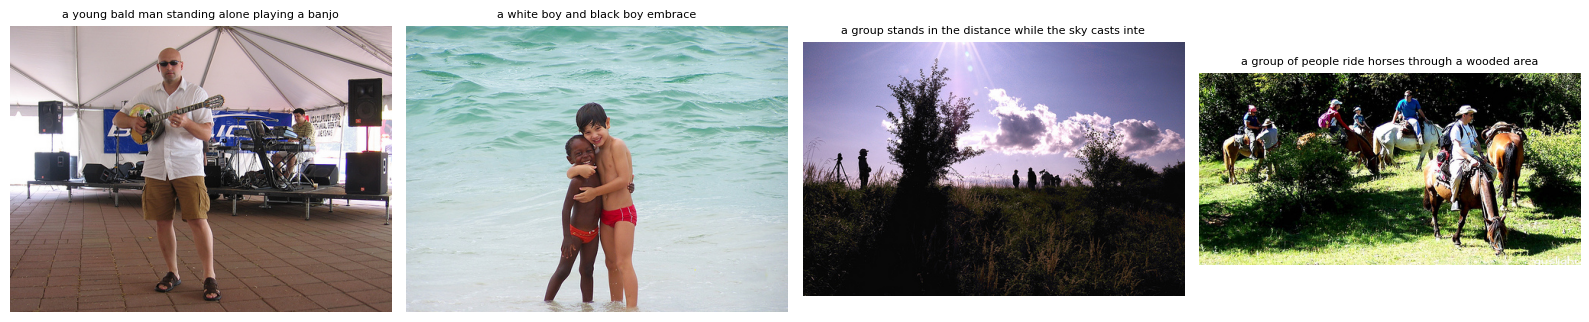

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (_, row) in zip(axes, train_df.sample(4, random_state=SEED).iterrows()):
    ax.imshow(Image.open(IMG_DIR / row["image"]).convert("RGB"))
    ax.set_title(row["caption"][:55], fontsize=8, wrap=True)
    ax.axis("off")
plt.tight_layout(); plt.show()


In [9]:
# ── Encoder: EfficientNet-B4 (pretrained on ImageNet) ────────────────────────
class EncoderCNN(nn.Module):
    def __init__(self, encoder_dim=1792, dropout=0.1):
        super().__init__()
        base = tvm.efficientnet_b4(weights=tvm.EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.dropout  = nn.Dropout2d(dropout)

        # Freeze everything first
        for p in self.features.parameters():
            p.requires_grad = False

        # Unfreeze only the last 2 blocks — enough to adapt, cheap on VRAM
        for p in self.features[7].parameters():
            p.requires_grad = True
        for p in self.features[8].parameters():
            p.requires_grad = True

    def forward(self, x):
        f = self.features(x)
        f = self.dropout(f)
        B, C, H, W = f.shape
        return f.view(B, C, H * W).permute(0, 2, 1)  # (B, H*W, 1792)

# ── Attention ─────────────────────────────────────────────────────────────────
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, hidden_size, attention_dim):
        super().__init__()
        self.W_h = nn.Linear(hidden_size,  attention_dim)
        self.W_a = nn.Linear(encoder_dim,  attention_dim)
        self.v   = nn.Linear(attention_dim, 1, bias=False)

    def forward(self, features, hidden):
        e = self.v(torch.tanh(self.W_h(hidden).unsqueeze(1) + self.W_a(features)))
        alpha   = F.softmax(e.squeeze(2), dim=1)
        context = (features * alpha.unsqueeze(2)).sum(1)
        return context, alpha


# ── Decoder ───────────────────────────────────────────────────────────────────
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, encoder_dim, vocab_size,
                 attention_dim, dropout=0.5):
        super().__init__()
        self.embed     = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.attention = BahdanauAttention(encoder_dim, hidden_size, attention_dim)
        self.lstm      = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.fc        = nn.Linear(hidden_size, vocab_size)
        self.dropout   = nn.Dropout(dropout)
        self.init_h    = nn.Linear(encoder_dim, hidden_size)
        self.init_c    = nn.Linear(encoder_dim, hidden_size)
        self.hidden_size = hidden_size
        self.vocab_size  = vocab_size

    def _init_hidden(self, features):
        m = features.mean(1)
        return torch.tanh(self.init_h(m)), torch.tanh(self.init_c(m))

    def forward(self, features, captions, lengths):
        B, T     = captions.shape
        embs     = self.dropout(self.embed(captions[:, :-1]))   # (B, T-1, E)
        h, c     = self._init_hidden(features)
        logits   = []
        for t in range(T - 1):
            ctx, _  = self.attention(features, h)
            h, c    = self.lstm(torch.cat([embs[:, t], ctx], 1), (h, c))
            logits.append(self.fc(self.dropout(h)))
        return torch.stack(logits, 1)   # (B, T-1, V)

    @torch.no_grad()
    def generate_beam(self, features, vocab, beam_width=5, max_len=30):
        self.eval()
        sos, eos = vocab.stoi[vocab.SOS], vocab.stoi[vocab.EOS]
        pad, unk = vocab.stoi[vocab.PAD], vocab.stoi[vocab.UNK]
        h0, c0   = self._init_hidden(features)
        beams    = [(0.0, [sos], h0, c0)]
        done     = []
        for _ in range(max_len):
            nxt = []
            for lp, ids, h, c in beams:
                if ids[-1] == eos:
                    done.append((lp, ids)); continue
                emb       = self.embed(torch.tensor([[ids[-1]]], device=features.device)).squeeze(1)
                ctx, _    = self.attention(features, h)
                h2, c2    = self.lstm(torch.cat([emb, ctx], 1), (h, c))
                log_p     = F.log_softmax(self.fc(h2), -1).squeeze(0)
                tk_lp, tk_id = log_p.topk(beam_width)
                for tlp, tid in zip(tk_lp.tolist(), tk_id.tolist()):
                    nxt.append((lp + tlp, ids + [tid], h2, c2))
            if not nxt: break
            nxt.sort(key=lambda x: x[0], reverse=True)
            beams = nxt[:beam_width]
        if not done: done = [(b[0], b[1]) for b in beams]
        _, best = max(done, key=lambda x: x[0])
        skip = {sos, eos, pad, unk}
        return [vocab.itos[i] for i in best if i not in skip]


# ── instantiate ───────────────────────────────────────────────────────────────
encoder = EncoderCNN(encoder_dim=ENCODER_DIM, dropout=0.1).to(DEVICE)
decoder = DecoderRNN(
    embed_size    = EMBED_SIZE,
    hidden_size   = HIDDEN_SIZE,
    encoder_dim   = ENCODER_DIM,
    vocab_size    = len(vocab),
    attention_dim = ATTENTION_DIM,
    dropout       = DROPOUT,
).to(DEVICE)

total = sum(p.numel() for p in list(encoder.parameters()) + list(decoder.parameters()))
print(f"Total parameters: {total:,}")

# shape check
with torch.no_grad():
    _f = encoder(torch.zeros(2, 3, 380, 380).to(DEVICE))
    _l = decoder(_f, torch.zeros(2, 10, dtype=torch.long).to(DEVICE), None)
    print(f"Encoder out: {_f.shape}  |  Decoder out: {_l.shape}")
print("Shape check passed.")


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 188MB/s] 


Total parameters: 30,309,996
Encoder out: torch.Size([2, 144, 1792])  |  Decoder out: torch.Size([2, 9, 3876])
Shape check passed.


In [10]:
pad_idx   = vocab.stoi[vocab.PAD]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx, label_smoothing=LABEL_SMOOTHING)

optimizer = optim.AdamW([
    {"params": filter(lambda p: p.requires_grad, encoder.parameters()), "lr": ENCODER_LR},
    {"params": decoder.parameters(), "lr": DECODER_LR},
], weight_decay=1e-4)

scaler = torch.amp.GradScaler('cuda')  # for mixed precision

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    p = (epoch - WARMUP_EPOCHS) / max(1, NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * p))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print("Optimiser ready")


Optimiser ready


In [11]:
from collections import Counter as _C

def _ng(tok, n): return _C(tuple(tok[i:i+n]) for i in range(len(tok)-n+1))

def corpus_bleu(hyps, refs, max_n=4):
    out = {}
    for n in range(1, max_n+1):
        num = den = 0
        for h, rs in zip(hyps, refs):
            hng  = _ng(h, n)
            rmax = _C()
            for r in rs:
                for ng in (rng := _ng(r, n)): rmax[ng] = max(rmax[ng], rng[ng])
            num += sum(min(c, rmax[ng]) for ng, c in hng.items())
            den += max(1, sum(hng.values()))
        out[f"bleu{n}"] = num / max(den, 1)
    return out

def evaluate_bleu(encoder, decoder, val_df, vocab, n=400):
    encoder.eval(); decoder.eval()
    imgs = val_df["image"].unique().tolist()
    random.shuffle(imgs); imgs = imgs[:n]
    hyps, refs = [], []
    with torch.no_grad():
        for name in imgs:
            t   = val_transform(Image.open(IMG_DIR / name).convert("RGB")).unsqueeze(0).to(DEVICE)
            f   = encoder(t)
            hyps.append(decoder.generate_beam(f, vocab, BEAM_WIDTH))
            refs.append([r.split() for r in val_df[val_df["image"]==name]["caption"].tolist()])
    return corpus_bleu(hyps, refs)


In [12]:
def run_epoch(loader, train):
    encoder.train(train); decoder.train(train)
    tot, ntok = 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, caps, lengths in tqdm(loader, desc="train" if train else "val  ", leave=False):
            imgs, caps = imgs.to(DEVICE), caps.to(DEVICE)

            with torch.autocast(device_type="cuda"):   # float16 where safe
                feat   = encoder(imgs)
                logits = decoder(feat, caps, lengths)
                tgt    = caps[:, 1:]
                loss   = criterion(logits.reshape(-1, len(vocab)), tgt.reshape(-1))

            if train:
                optimizer.zero_grad(set_to_none=True)   # faster + frees memory immediately
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                trainable = [p for p in encoder.parameters() if p.requires_grad] + \
                            list(decoder.parameters())
                nn.utils.clip_grad_norm_(trainable, 5.0)
                scaler.step(optimizer)
                scaler.update()

            mask  = tgt.reshape(-1) != pad_idx
            tot  += loss.item() * mask.sum().item()
            ntok += mask.sum().item()
    return tot / max(ntok, 1)


train_losses, val_losses, bleu1s, bleu4s = [], [], [], []
best_val = math.inf

torch.cuda.empty_cache()

print(f"Training {NUM_EPOCHS} epochs on {DEVICE}\n")
for epoch in range(1, NUM_EPOCHS + 1):
    tl = run_epoch(train_loader, True)
    vl = run_epoch(val_loader,   False)
    scheduler.step()

    bleu = evaluate_bleu(encoder, decoder, val_df, vocab)
    b1, b4 = bleu["bleu1"], bleu["bleu4"]
    train_losses.append(tl); val_losses.append(vl)
    bleu1s.append(b1);       bleu4s.append(b4)

    enc_lr = optimizer.param_groups[0]["lr"]
    dec_lr = optimizer.param_groups[1]["lr"]
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  train={tl:.4f}  val={vl:.4f}  "
          f"ppl={math.exp(min(vl,10)):.2f}  BLEU-1={b1:.3f}  BLEU-4={b4:.3f}  "
          f"enc_lr={enc_lr:.1e}  dec_lr={dec_lr:.1e}")

    if vl < best_val:
        best_val = vl
        torch.save(encoder.state_dict(), MODEL_DIR / "encoder_best.pth")
        torch.save(decoder.state_dict(), MODEL_DIR / "decoder_best.pth")
        print(f"  ✓ Saved (val={best_val:.4f})")


Training 20 epochs on cuda



train:   0%|          | 0/2276 [00:00<?, ?it/s]

val  :   0%|          | 0/253 [00:00<?, ?it/s]

Epoch 01/20  train=4.7346  val=4.1247  ppl=61.85  BLEU-1=0.588  BLEU-4=0.051  enc_lr=1.0e-04  dec_lr=4.0e-04
  ✓ Saved (val=4.1247)


train:   0%|          | 0/2276 [00:00<?, ?it/s]

...

val  :   0%|          | 0/253 [00:00<?, ?it/s]

Epoch 19/20  train=3.0931  val=3.4389  ppl=31.15  BLEU-1=0.690  BLEU-4=0.099  enc_lr=7.6e-07  dec_lr=3.0e-06
  ✓ Saved (val=3.4389)


train:   0%|          | 0/2276 [00:00<?, ?it/s]

val  :   0%|          | 0/253 [00:00<?, ?it/s]

Epoch 20/20  train=3.0903  val=3.4387  ppl=31.15  BLEU-1=0.696  BLEU-4=0.099  enc_lr=0.0e+00  dec_lr=0.0e+00
  ✓ Saved (val=3.4387)


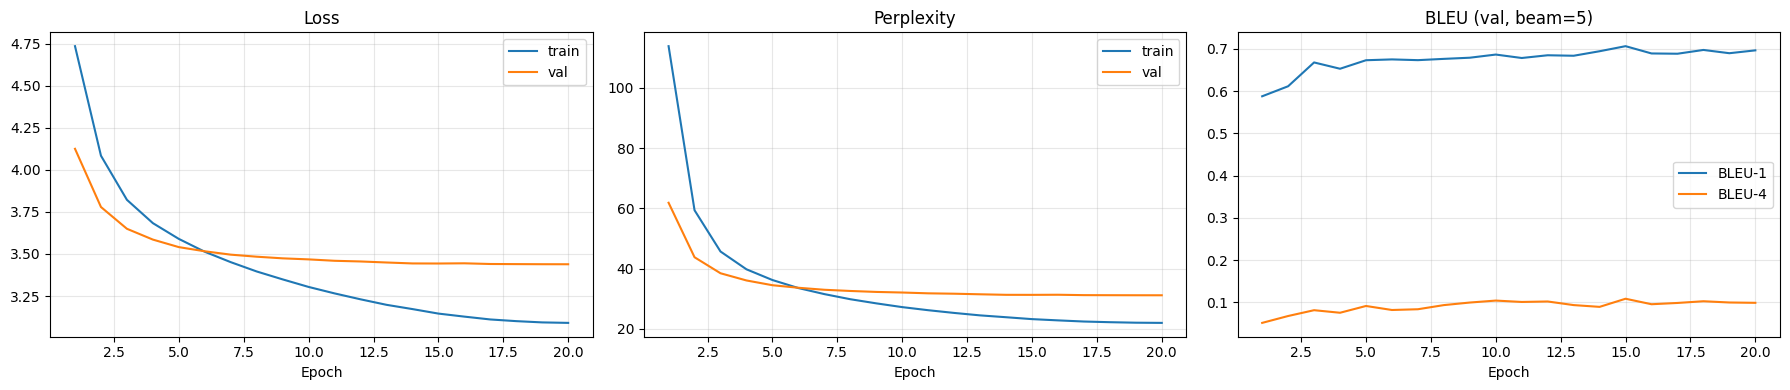

In [13]:
ep = range(1, len(train_losses)+1)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(ep, train_losses, label="train"); axes[0].plot(ep, val_losses, label="val")
axes[0].set(title="Loss", xlabel="Epoch"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(ep, [math.exp(min(l,10)) for l in train_losses], label="train")
axes[1].plot(ep, [math.exp(min(l,10)) for l in val_losses],   label="val")
axes[1].set(title="Perplexity", xlabel="Epoch"); axes[1].legend(); axes[1].grid(alpha=.3)
axes[2].plot(ep, bleu1s, label="BLEU-1"); axes[2].plot(ep, bleu4s, label="BLEU-4")
axes[2].set(title="BLEU (val, beam=5)", xlabel="Epoch"); axes[2].legend(); axes[2].grid(alpha=.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / "curves.png", dpi=150)
plt.show()


In [14]:
torch.save(encoder.state_dict(), MODEL_DIR / "encoder_final.pth")
torch.save(decoder.state_dict(), MODEL_DIR / "decoder_final.pth")

cfg = {
    "encoder":        "efficientnet_b4",
    "encoder_dim":    ENCODER_DIM,
    "embed_size":     EMBED_SIZE,
    "hidden_size":    HIDDEN_SIZE,
    "attention_dim":  ATTENTION_DIM,
    "dropout":        DROPOUT,
    "vocab_size":     len(vocab),
    "max_seq_len":    MAX_SEQ_LEN,
    "beam_width":     BEAM_WIDTH,
    "best_val_loss":  best_val,
    "final_bleu1":    bleu1s[-1] if bleu1s else None,
    "final_bleu4":    bleu4s[-1] if bleu4s else None,
}
with open(MODEL_DIR / "config.json", "w") as f:
    json.dump(cfg, f, indent=2)

print("Artifacts:")
for p in sorted(MODEL_DIR.iterdir()):
    print(f"  {p.name}  {p.stat().st_size/1024:.1f} KB")

try:
    from google.colab import files
    for p in [MODEL_DIR/"encoder_best.pth", MODEL_DIR/"decoder_best.pth",
              MODEL_DIR/"vocab.pkl", MODEL_DIR/"config.json"]:
        if p.exists(): files.download(str(p)); print(f"  ↓ {p.name}")
except ImportError:
    print("(Not Colab — files saved to models/)")


Artifacts:
  config.json  0.3 KB
  curves.png  94.8 KB
  decoder_best.pth  49855.2 KB
  decoder_final.pth  49855.2 KB
  encoder_best.pth  69290.3 KB
  encoder_final.pth  69291.0 KB
  vocab.pkl  75.6 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ encoder_best.pth


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ↓ vocab.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ↓ config.json


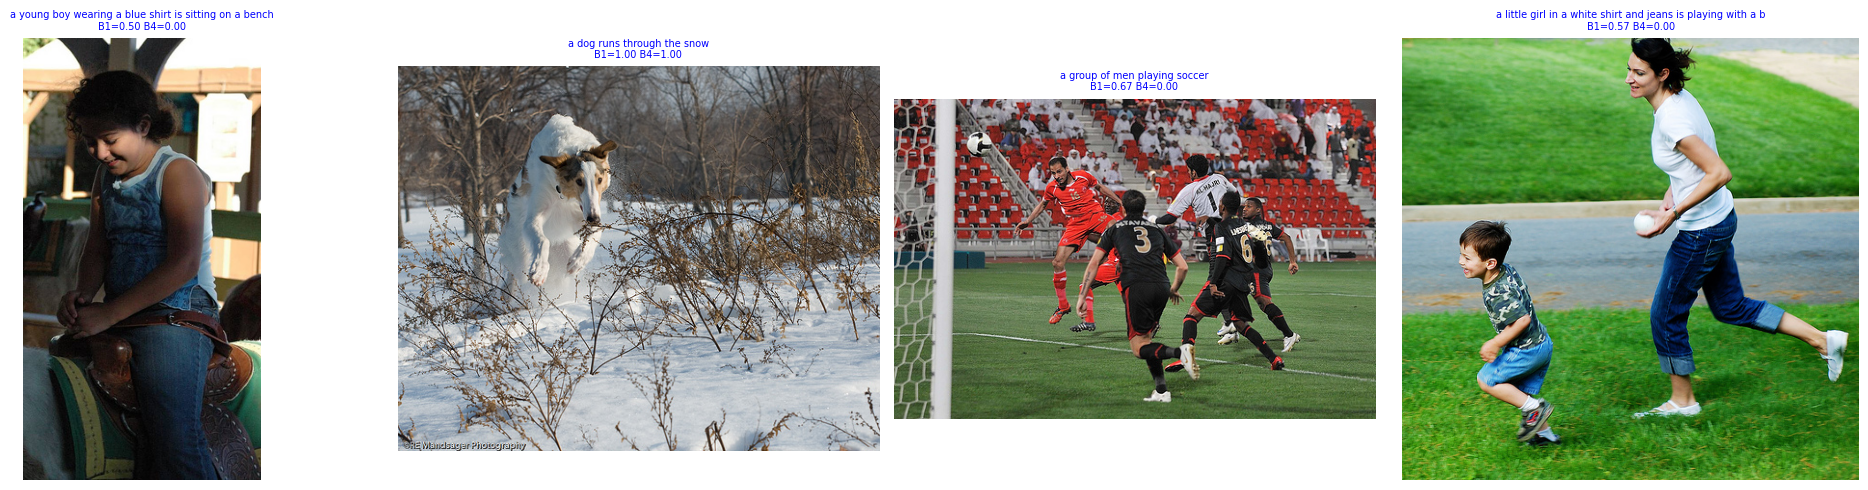


Image   : 282960970_574aa1ba49.jpg
Caption : a young boy wearing a blue shirt is sitting on a bench

References:
  1. a person wearing jeans sits on top of a horse saddle
  2. a woman in jeans is sitting on the saddle of a horse
  3. the girl is sitting on top of a saddle
  4. the person is sitting on top of a horse
  5. this person is sitting in a saddle

──────────────────────────────────────────────────
Upload your own image:


FileUpload(value=(), accept='image/*', description='Upload')

Output()

In [19]:
import io
import ipywidgets as widgets
from IPython.display import display, clear_output

encoder.load_state_dict(torch.load(MODEL_DIR/"encoder_best.pth", map_location=DEVICE))
decoder.load_state_dict(torch.load(MODEL_DIR/"decoder_best.pth", map_location=DEVICE))
encoder.eval(); decoder.eval()

def caption_image(img):
    t = val_transform(img.convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        f    = encoder(t)
        toks = decoder.generate_beam(f, vocab, BEAM_WIDTH)
    return toks

# ── sample grid (unchanged) ──────────────────────────────────────────────────
sample_imgs = val_df["image"].unique().tolist()
random.shuffle(sample_imgs)
sample_imgs = sample_imgs[:4]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, sample_imgs):
    img  = Image.open(IMG_DIR/name)
    toks = caption_image(img)
    refs = val_df[val_df["image"]==name]["caption"].tolist()
    bleu = corpus_bleu([toks], [[r.split() for r in refs]])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{' '.join(toks)[:60]}\nB1={bleu['bleu1']:.2f} B4={bleu['bleu4']:.2f}",
                 fontsize=7, color="blue")
plt.tight_layout()
plt.savefig(MODEL_DIR/"samples.png", dpi=150)
plt.show()

# ── full printout for first val image (unchanged) ────────────────────────────
name = sample_imgs[0]
toks = caption_image(Image.open(IMG_DIR/name))
print(f"\nImage   : {name}")
print(f"Caption : {' '.join(toks)}")
print("\nReferences:")
for i, r in enumerate(val_df[val_df["image"]==name]["caption"].tolist(), 1):
    print(f"  {i}. {r}")

# ── upload widget ─────────────────────────────────────────────────────────────
print("\n" + "─"*50)
print("Upload your own image:")

upload = widgets.FileUpload(accept="image/*", multiple=False)
out    = widgets.Output()

def on_upload(change):
    with out:
        clear_output()
        # newer ipywidgets: upload.value is a tuple of dicts
        file_info = upload.value[0]
        data = file_info["content"]
        img  = Image.open(io.BytesIO(data))
        toks = caption_image(img)

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(' '.join(toks), fontsize=10, color="blue")
        plt.tight_layout()
        plt.show()
        print(f"Caption: {' '.join(toks)}")

upload.observe(on_upload, names="value")
display(upload, out)